<a href="https://colab.research.google.com/github/VinnyVolkov/python_project1/blob/main/Python_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
# Грузимо всі необіхідні бібліотекти
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter



In [45]:
# Підключаємо файл
from google.colab import drive
drive.mount("/content/drive")

%cd /content/drive/MyDrive/MateHomework/13. Final project

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/MateHomework/13. Final project


In [46]:
# Перевіряємо зміст файлів
countries = pd.read_csv("countries.csv")
countries.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


Бачимо такі колонки у  табличці *Countries*


- **name** — назва країни.

- **alpha-2** — дволітерний міжнародний код країни (ISO 3166-1 Alpha-2).

- **alpha-3** — трилітерний міжнародний код країни (ISO 3166-1 Alpha-3).

- **region** — географічний регіон, до якого належить країна.

- **sub-region** — географічний підрегіон, до якого належить країна.


In [47]:
events = pd.read_csv("events.csv")
events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


Бачимо такі колонки у табличці *Events*.

- **Order ID** — унікальний ідентифікатор замовлення.

- **Order Date** — дата оформлення замовлення.

- **Ship Date** — дата відправлення замовлення.

- **Order Priority** — пріоритет замовлення.

- **Country Code** — дволітерний міжнародний код країни.

- **Product ID** — унікальний ідентифікатор товару.

- **Sales Channel** — канал продажу (Online або Offline).

- **Units Sold** — кількість проданих одиниць товару.

- **Unit Price** — ціна за одну одиницю товару.

- **Unit Cost** — собівартість однієї одиниці товару.

In [48]:
products = pd.read_csv("products.csv")
products.head()

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


Бачимо такі колонки у табличці *Products*.

- **id** — унікальний ідентифікатор товару.

- **item_type** — назва або категорія товару.

Щоб обєднати event + products

Для event ми беремо колонку Product ID для табличкі product колонку id

Щоб об'єднати event + countries

Для event ми беремо Country Code для табличкі countries беремо колонку alpha-3


In [49]:
# Перегляд інформацію для очищення даних та перевіряємо чи правильний формат у даних
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


Є тут пару пропущених значень формат у всіх мені об'єкт для категорій це те що треба

In [50]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


Є пропущені значення будесо вирішувати що з ними робити

Колонка **Order Date** i **Ship Date** записані не у форматі дати  треба замінити

Для себе це не обов'язково хочу замінити колонки **Product ID**  та  **Order ID** на рядок бо це будуть наші ключі не числові дані

In [51]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


Тут все добре міняти нічого не потрібно

In [52]:
# Вирішуємо що робити з пустими даними у табличці event
(events["Country Code"].isna().mean() * 100 ).round(2)

np.float64(6.17)

Бачимо що пусті коди країн займають 6 % сутєво впливають на аналіз даних, видалити рядкі з пустими значенями ми не можемо тоді замінюємо їх на Unknown

In [53]:
events["Country Code"] = events["Country Code"].fillna("Unknown")

Так як ще маємо пусті значеня в колонці Units Sold замінямо їх на середнє значеня по колонці

In [54]:
events["Units Sold"] = events['Units Sold'].fillna(events['Units Sold'].mean())

Виправиляємо на вірний формат

In [55]:
# Виправляємо це
events['Order Date'] = pd.to_datetime(events['Order Date'])
events['Ship Date'] = pd.to_datetime(events['Ship Date'])


In [56]:
# Перевіряємо чи все вийшло
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1330 non-null   int64         
 1   Order Date      1330 non-null   datetime64[ns]
 2   Ship Date       1330 non-null   datetime64[ns]
 3   Order Priority  1330 non-null   object        
 4   Country Code    1330 non-null   object        
 5   Product ID      1330 non-null   int64         
 6   Sales Channel   1330 non-null   object        
 7   Units Sold      1330 non-null   float64       
 8   Unit Price      1330 non-null   float64       
 9   Unit Cost       1330 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 104.0+ KB


Очищаємо пусті дані в таблиці countries

In [57]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


Перевіряємо пусте значення в **alpha-2**

In [58]:
countries[countries["alpha-2"].isna()]

,name,alpha-2,alpha-3,region,sub-region
153,Namibia,NaN,NAM,Africa,Sub-Saharan Africa


Міняємо пусте значеня на **NA** щоб не було Nan

In [59]:
countries["alpha-2"] = countries["alpha-2"].fillna("NA")

Так само перевіряємо **region** тa **sub_region**

In [60]:
countries[countries[["region","sub-region"]].isna().any(axis=1)]

,name,alpha-2,alpha-3,region,sub-region
8,Antarctica,AQ,ATA,NaN,NaN


In [61]:
# Заповнюємо пусті значеня
countries['sub-region'] = countries["sub-region"].fillna("Unknow sub-region")
countries["alpha-2"] = countries["alpha-2"].fillna("NA")

Перевіряємо чи все вийшло

In [62]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     249 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  249 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


Обєднуємо табличкі разом

In [63]:
events = (events.merge(products, left_on='Product ID', right_on='id', how="left")).drop(columns="id")
events.rename(columns={"item_type": "Category"}, inplace=True)
events = (events.merge(countries[['alpha-3',"name", "region","sub-region"]], left_on='Country Code', right_on="alpha-3", how="left")).drop(columns="alpha-3")
events.rename(columns={"name": "Country"}, inplace=True)
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1330 non-null   int64         
 1   Order Date      1330 non-null   datetime64[ns]
 2   Ship Date       1330 non-null   datetime64[ns]
 3   Order Priority  1330 non-null   object        
 4   Country Code    1330 non-null   object        
 5   Product ID      1330 non-null   int64         
 6   Sales Channel   1330 non-null   object        
 7   Units Sold      1330 non-null   float64       
 8   Unit Price      1330 non-null   float64       
 9   Unit Cost       1330 non-null   float64       
 10  Category        1330 non-null   object        
 11  Country         1248 non-null   object        
 12  region          1248 non-null   object        
 13  sub-region      1248 non-null   object        
dtypes: datetime64[ns](2), float64(3), int64(2), object(7)
me

Після того як ми обєднали табличкі бачисо що в нас є пусті значеня замінимо їх на Unknown

In [64]:
events['Country'] = events['Country'].fillna("Unknow country")
events['sub-region'] = events["sub-region"].fillna("Unknow sub-region")
events['region'] = events["region"].fillna("Unknow region")


In [65]:
# Перевіряємо
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1330 non-null   int64         
 1   Order Date      1330 non-null   datetime64[ns]
 2   Ship Date       1330 non-null   datetime64[ns]
 3   Order Priority  1330 non-null   object        
 4   Country Code    1330 non-null   object        
 5   Product ID      1330 non-null   int64         
 6   Sales Channel   1330 non-null   object        
 7   Units Sold      1330 non-null   float64       
 8   Unit Price      1330 non-null   float64       
 9   Unit Cost       1330 non-null   float64       
 10  Category        1330 non-null   object        
 11  Country         1330 non-null   object        
 12  region          1330 non-null   object        
 13  sub-region      1330 non-null   object        
dtypes: datetime64[ns](2), float64(3), int64(2), object(7)
me

Робимо назви колонок у одному регістрі

In [66]:
events.columns = events.columns.str.title()
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order Id        1330 non-null   int64         
 1   Order Date      1330 non-null   datetime64[ns]
 2   Ship Date       1330 non-null   datetime64[ns]
 3   Order Priority  1330 non-null   object        
 4   Country Code    1330 non-null   object        
 5   Product Id      1330 non-null   int64         
 6   Sales Channel   1330 non-null   object        
 7   Units Sold      1330 non-null   float64       
 8   Unit Price      1330 non-null   float64       
 9   Unit Cost       1330 non-null   float64       
 10  Category        1330 non-null   object        
 11  Country         1330 non-null   object        
 12  Region          1330 non-null   object        
 13  Sub-Region      1330 non-null   object        
dtypes: datetime64[ns](2), float64(3), int64(2), object(7)
me

Підготовлюємо дані для перевірки даних (зводимо до одного рестрі прибираємо зайві пробіли )

In [67]:
text = events.select_dtypes(include="object").columns
events[text] = events[text].apply(lambda col: col.str.strip().str.title())

Перевіряємо

In [68]:
events.head()

,Order Id,Order Date,Ship Date,Order Priority,Country Code,Product Id,Sales Channel,Units Sold,Unit Price,Unit Cost,Category,Country,Region,Sub-Region
0,100640618,2014-10-08,2014-10-18,M,Nor,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,Srb,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693.0,668.27,502.54,Household,Unknow Country,Unknow Region,Unknow Sub-Region
3,102230632,2017-05-13,2017-06-13,L,Mne,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,Srb,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe


Перевіряємо на дублікати таблцю

In [69]:
print(f"Кількість копій у табличці Events: {events.duplicated().sum()}")


Кількість копій у табличці Events: 0


Дублікатів немає тому перевріяємо на аномаліїї та
перепишимо код на великий регістр для зручності

In [70]:
events["Country Code"] = events['Country Code'].str.upper()

In [71]:
events[["Units Sold","Unit Price","Unit Cost"]].describe()

,Units Sold,Unit Price,Unit Cost
count,1330.000000,1330.000000,1330.000000
mean,4952.201807,264.893541,187.246812
std,2903.012170,217.323460,176.158873
min,2.000000,9.330000,6.920000
25%,2360.750000,81.730000,35.840000
50%,4958.000000,154.060000,97.440000
75%,7458.750000,437.200000,263.330000
max,9999.000000,668.270000,524.960000


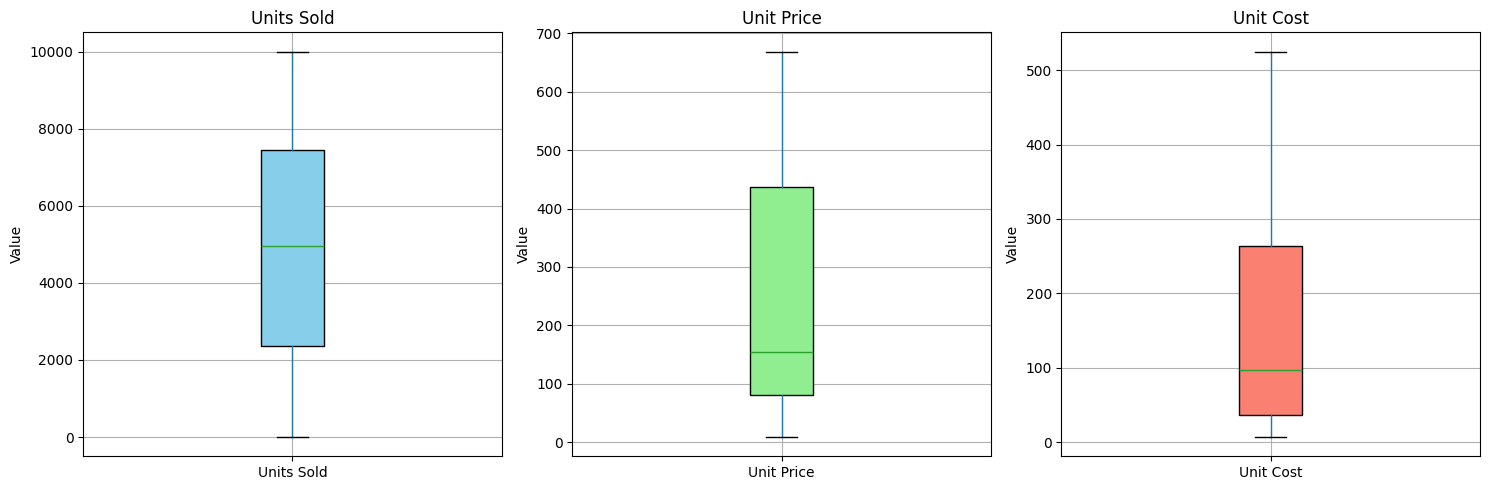

In [72]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Units Sold
events.boxplot(
    column="Units Sold",
    ax=ax[0],
    patch_artist=True,
    boxprops=dict(facecolor="skyblue")
)
ax[0].set_title("Units Sold")
ax[0].set_ylabel("Value")

# Unit Price
events.boxplot(
    column="Unit Price",
    ax=ax[1],
    patch_artist=True,
    boxprops=dict(facecolor="lightgreen")
)
ax[1].set_title("Unit Price")
ax[1].set_ylabel("Value")

# Unit Cost
events.boxplot(
    column="Unit Cost",
    ax=ax[2],
    patch_artist=True,
    boxprops=dict(facecolor="salmon")
)
ax[2].set_title("Unit Cost")
ax[2].set_ylabel("Value")

plt.tight_layout()
plt.show()

За результатами аналізу boxplot явних аномальних значень (викидів) у змінних Units Sold, Unit Price та Unit Cost не виявлено, оскільки відсутні точки за межами "вусів". Дані мають досить широкий діапазон значень, особливо для Unit Price, що свідчить про значну різноманітність цін товарів.

Знаходимо загальній приботок, загаліьні витрати, загальний прибуток

In [73]:
events["Total Revenue"] = events['Units Sold'] * events['Unit Price']
events["Total Cost"] = events['Units Sold'] * events['Unit Cost']
events["Total Profit"] = events['Total Revenue'] - events['Total Cost']
events.head()

,Order Id,Order Date,Ship Date,Order Priority,Country Code,Product Id,Sales Channel,Units Sold,Unit Price,Unit Cost,Category,Country,Region,Sub-Region,Total Revenue,Total Cost,Total Profit
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87
2,101025998,2014-07-18,2014-08-11,M,UNKNOWN,7940,Online,4693.0,668.27,502.54,Household,Unknow Country,Unknow Region,Unknow Sub-Region,3136191.11,2358420.22,777770.89
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68


Знайдемо ще кількість днів на доставку


In [74]:
events["Count Day"] = (events["Ship Date"] - events["Order Date"]).dt.days
events.head()

,Order Id,Order Date,Ship Date,Order Priority,Country Code,Product Id,Sales Channel,Units Sold,Unit Price,Unit Cost,Category,Country,Region,Sub-Region,Total Revenue,Total Cost,Total Profit,Count Day
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50,10
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87,0
2,101025998,2014-07-18,2014-08-11,M,UNKNOWN,7940,Online,4693.0,668.27,502.54,Household,Unknow Country,Unknow Region,Unknow Sub-Region,3136191.11,2358420.22,777770.89,24
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24,31
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68,38


Створимо базові метрики


In [75]:
revenue = events["Total Revenue"].sum()
cost = events["Total Cost"].sum()
profit = events["Total Profit"].sum()



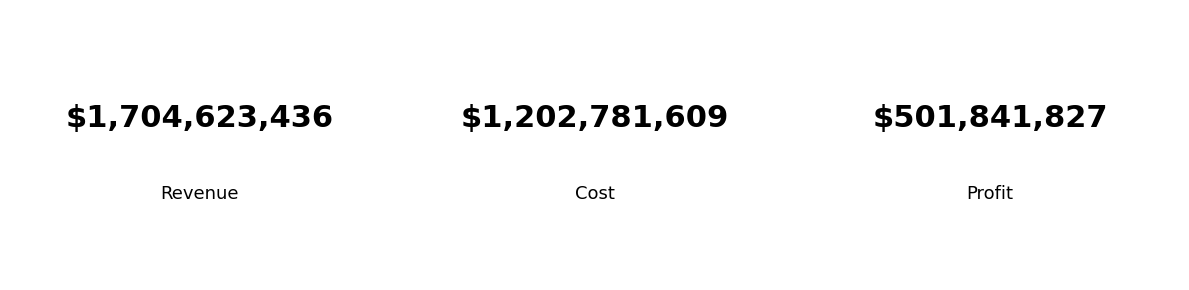

In [76]:
#  Створюємо базову метрику по грошам
fig, ax = plt.subplots(1, 3, figsize=(12, 3))

metrics = [
    ("Revenue", revenue),
    ("Cost", cost),
    ("Profit", profit)
]

for i, (title, value) in enumerate(metrics):
    ax[i].axis("off")

    ax[i].text(
        0.5, 0.6,
        f"${value:,.0f}",
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold"
    )

    ax[i].text(
        0.5, 0.3,
        title,
        ha="center",
        fontsize=13
    )

plt.tight_layout()
plt.show()

З цими даними ми можемо оцінити % прибутку

In [77]:
margin_precent = ((profit / revenue) * 100).round(2)


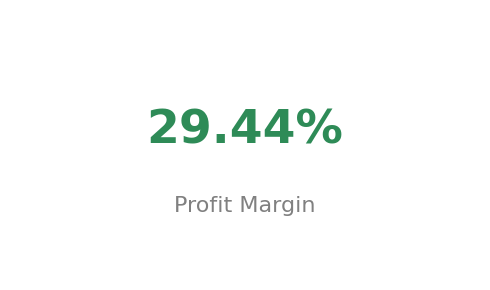

In [78]:
fig, ax = plt.subplots(figsize=(5, 3))

# KPI
ax.text(
    0.5,
    0.55,
    f"{margin_precent:.2f}%",
    fontsize=34,
    fontweight="bold",
    color="#2E8B57",
    ha="center",
    va="center"
)


ax.text(
    0.5,
    0.25,
    "Profit Margin",
    fontsize=16,
    color="gray",
    ha="center"
)


ax.axis("off")

plt.tight_layout()
plt.show()

Бачимо заробили 29.44% доволі добре для бізнесу

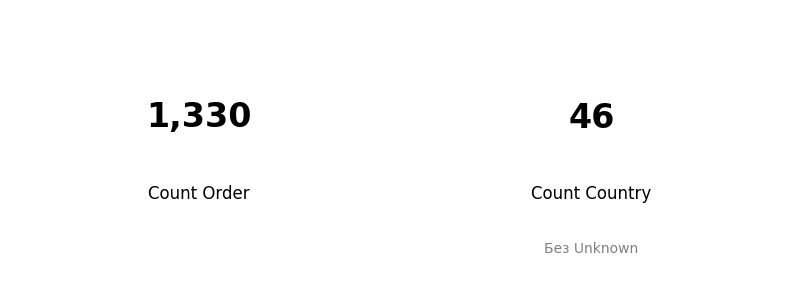

In [79]:
# Показали кількість замолень та кількість країн

import matplotlib.pyplot as plt


count_order = events["Order Id"].count()
count_country = events[events["Country"] != "Unknown"]["Country"].nunique()

fig, ax = plt.subplots(1, 2, figsize=(8, 3))


for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.set_frame_on(False)


ax[0].text(
    0.5, 0.6,
    f"{count_order:,.0f}",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold"
)

ax[0].text(
    0.5, 0.3,
    "Count Order",
    ha="center",
    fontsize=12
)


ax[1].text(
    0.5, 0.6,
    f"{count_country:,.0f}",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold"
)

ax[1].text(
    0.5, 0.3,
    "Count Country",
    ha="center",
    fontsize=12
)

ax[1].text(
    0.5, 0.1,
    "Без Unknown",
    ha="center",
    fontsize=10,
    color="gray"
)

plt.tight_layout()
plt.show()

Проаналізуємо продажі по таким критеріям(Приботуток, витрати , дохід):

* категорій товарів;
* географії (країн, регіонів);
* каналів продажу (онлайн або офлайн).

Візуалізаці по категоріям:

In [80]:
category = events.groupby("Category")[["Total Revenue", "Total Cost", "Total Profit"]].sum()

category["Profit Margin"] = (
    category["Total Profit"] / category["Total Revenue"] * 100
).round(1)

category_count = events.groupby("Category")["Units Sold"].sum()


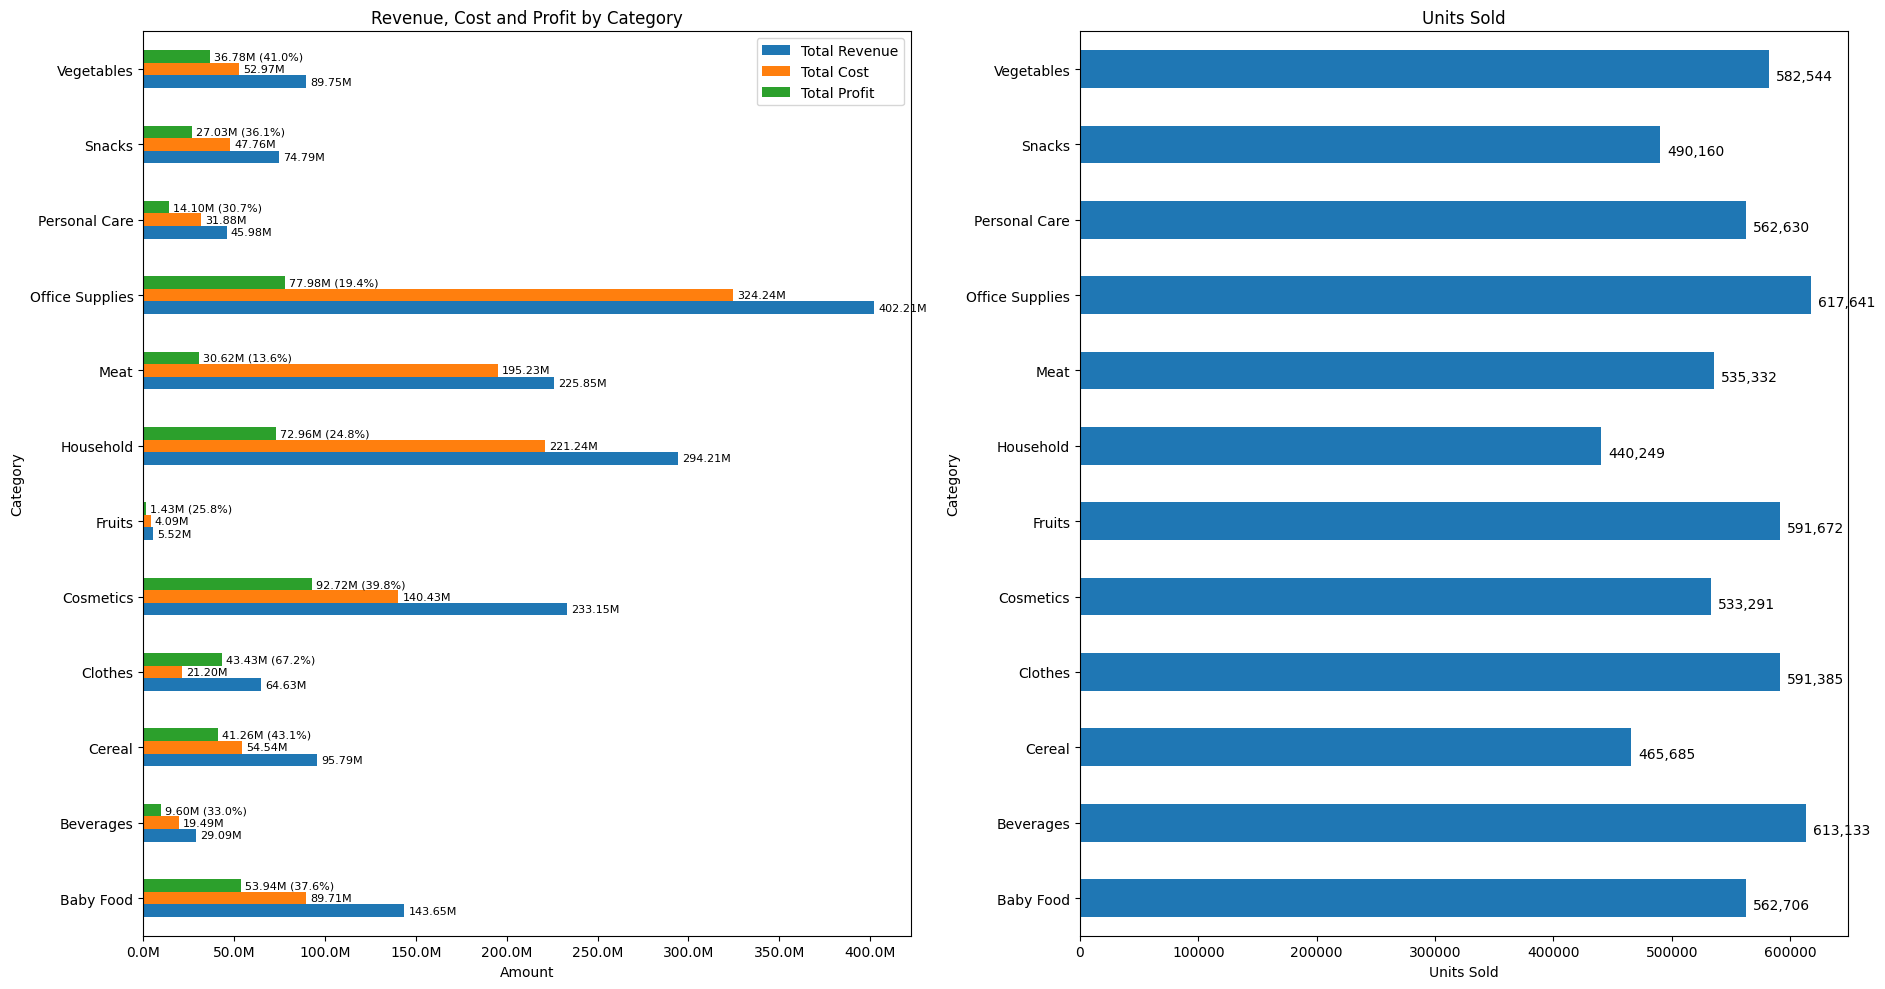

In [81]:
fig, ax = plt.subplots(1, 2, figsize=(19, 10))
category[["Total Revenue", "Total Cost", "Total Profit"]].plot(
    kind="barh",
    ax=ax[0]
)

ax[0].set_title("Revenue, Cost and Profit by Category")
ax[0].set_xlabel("Amount")
ax[0].set_ylabel("Category")

ax[0].xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f}M")
)

for container in ax[0].containers:

    labels = []

    for i, value in enumerate(container.datavalues):

        if container.get_label() == "Total Profit":

            margin = category["Profit Margin"].iloc[i]

            labels.append(
                f"{value/1_000_000:.2f}M ({margin:.1f}%)"
            )

        else:

            labels.append(
                f"{value/1_000_000:.2f}M"
            )

    ax[0].bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=8
    )

category_count.plot(
    kind="barh",
    ax=ax[1]
)

ax[1].set_title("Units Sold")
ax[1].set_xlabel("Units Sold")
ax[1].set_ylabel("Category")

for i, value in enumerate(category_count):
    ax[1].annotate(
        text=f"{value:,.0f}",
        xy=(value, i),
        xytext=(5, -5),
        textcoords="offset points",
        ha="left",
        va="center"
    )

plt.tight_layout()
plt.show()

Бачимо що у Office Supplies найбільший прибуток 402.21 млн але профіт лише 77.98 (***19.4%***)

А у Clothes прибуток лише 64.63 млн, зате профіт 43,43 млн (***67.2%***)

Якщо дивтись на кілкість проданих товарів то у Office Supplies не набагато більше по кількісті проданих товарів ніж у Clothes

Тому робимо висновок що категорія **Clothes** більше вигідніше ніж **Office Supplies** по профіту бачимо що велику роль зіграли витрати у **Clothes** це **21.20 млн**, а у **Office Supplies** це **324.24 млн**


Решта товарів доволі непогано показли у відношені Прибуток Витрати

Візуалізація по регіонам:

In [82]:
region = events.groupby("Region")[["Total Revenue", "Total Cost", "Total Profit"]].sum()


region["Profit Margin"] = (
    region["Total Profit"] / region["Total Revenue"] * 100
).round(1)


region_count = events.groupby("Region")["Units Sold"].sum()

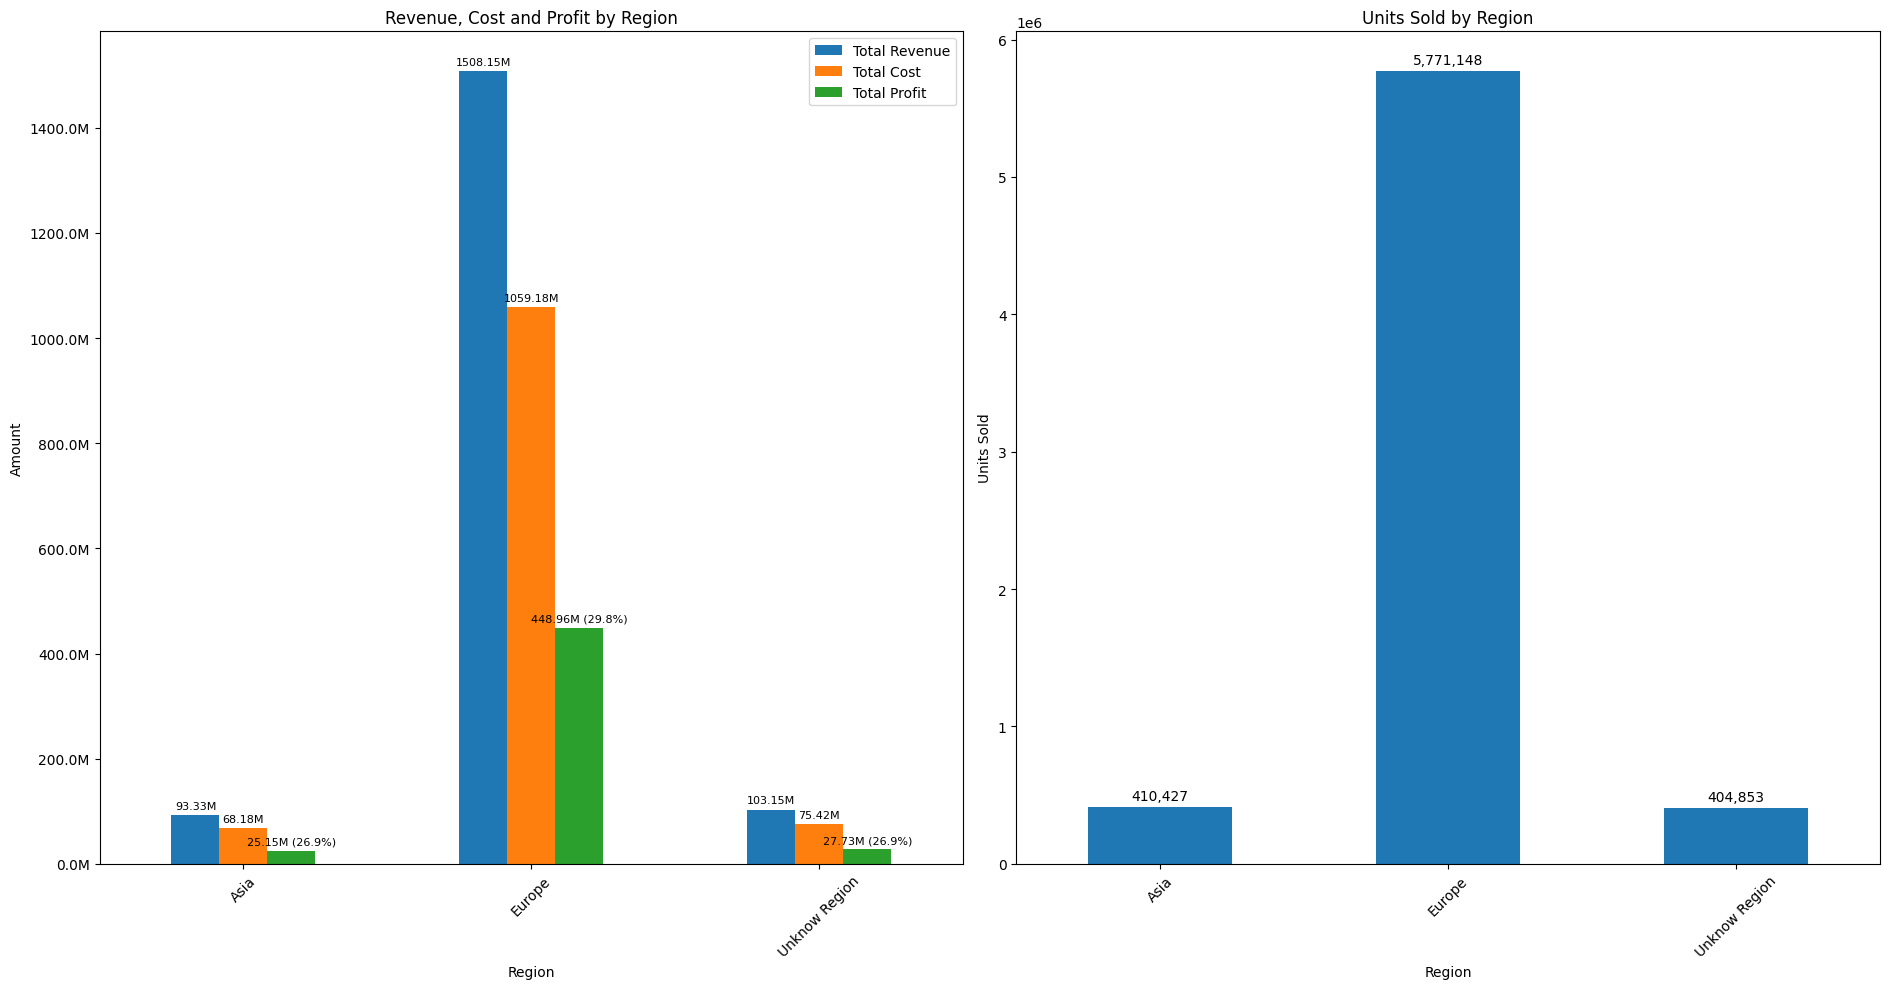

In [83]:
fig, ax = plt.subplots(1, 2, figsize=(19, 10))


region[["Total Revenue", "Total Cost", "Total Profit"]].plot(
    kind="bar",
    ax=ax[0],
    rot=45
)

ax[0].set_title("Revenue, Cost and Profit by Region")
ax[0].set_xlabel("Region")
ax[0].set_ylabel("Amount")


ax[0].yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f}M")
)


for container in ax[0].containers:

    labels = []

    for i, value in enumerate(container.datavalues):


        if container.get_label() == "Total Profit":

            margin = region["Profit Margin"].iloc[i]

            labels.append(
                f"{value/1_000_000:.2f}M ({margin:.1f}%)"
            )


        else:

            labels.append(
                f"{value/1_000_000:.2f}M"
            )

    ax[0].bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=8
    )


region_count.plot(
    kind="bar",
    ax=ax[1],
    rot=45
)

ax[1].set_title("Units Sold by Region")
ax[1].set_xlabel("Region")
ax[1].set_ylabel("Units Sold")

for i, value in enumerate(region_count):

    ax[1].annotate(
        text=f"{value:,.0f}",
        xy=(i, value),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

По регіонам ситуація інша Європа є лідером серед прибутку і у відстотку по профіту і навіть по кількості проданих товарів

Хоча і Азія себе не погано показує не дивлячись на кількість проданих товарів доволі хороший профіт тому можна спробувати на Азію також зробити акцент

Візуалізація по топ 5 країн за профітом та за кількості проданих товарів:

In [84]:
country = (
    events.groupby("Country")[["Total Revenue", "Total Cost", "Total Profit"]]
    .sum()
    .sort_values("Total Profit", ascending=False)
    .head(5)
)

country["Profit Margin"] = (
    country["Total Profit"] / country["Total Revenue"] * 100
).round(1)

country_units = (
    events.groupby("Country")["Units Sold"]
    .sum()
    .loc[country.index]
)

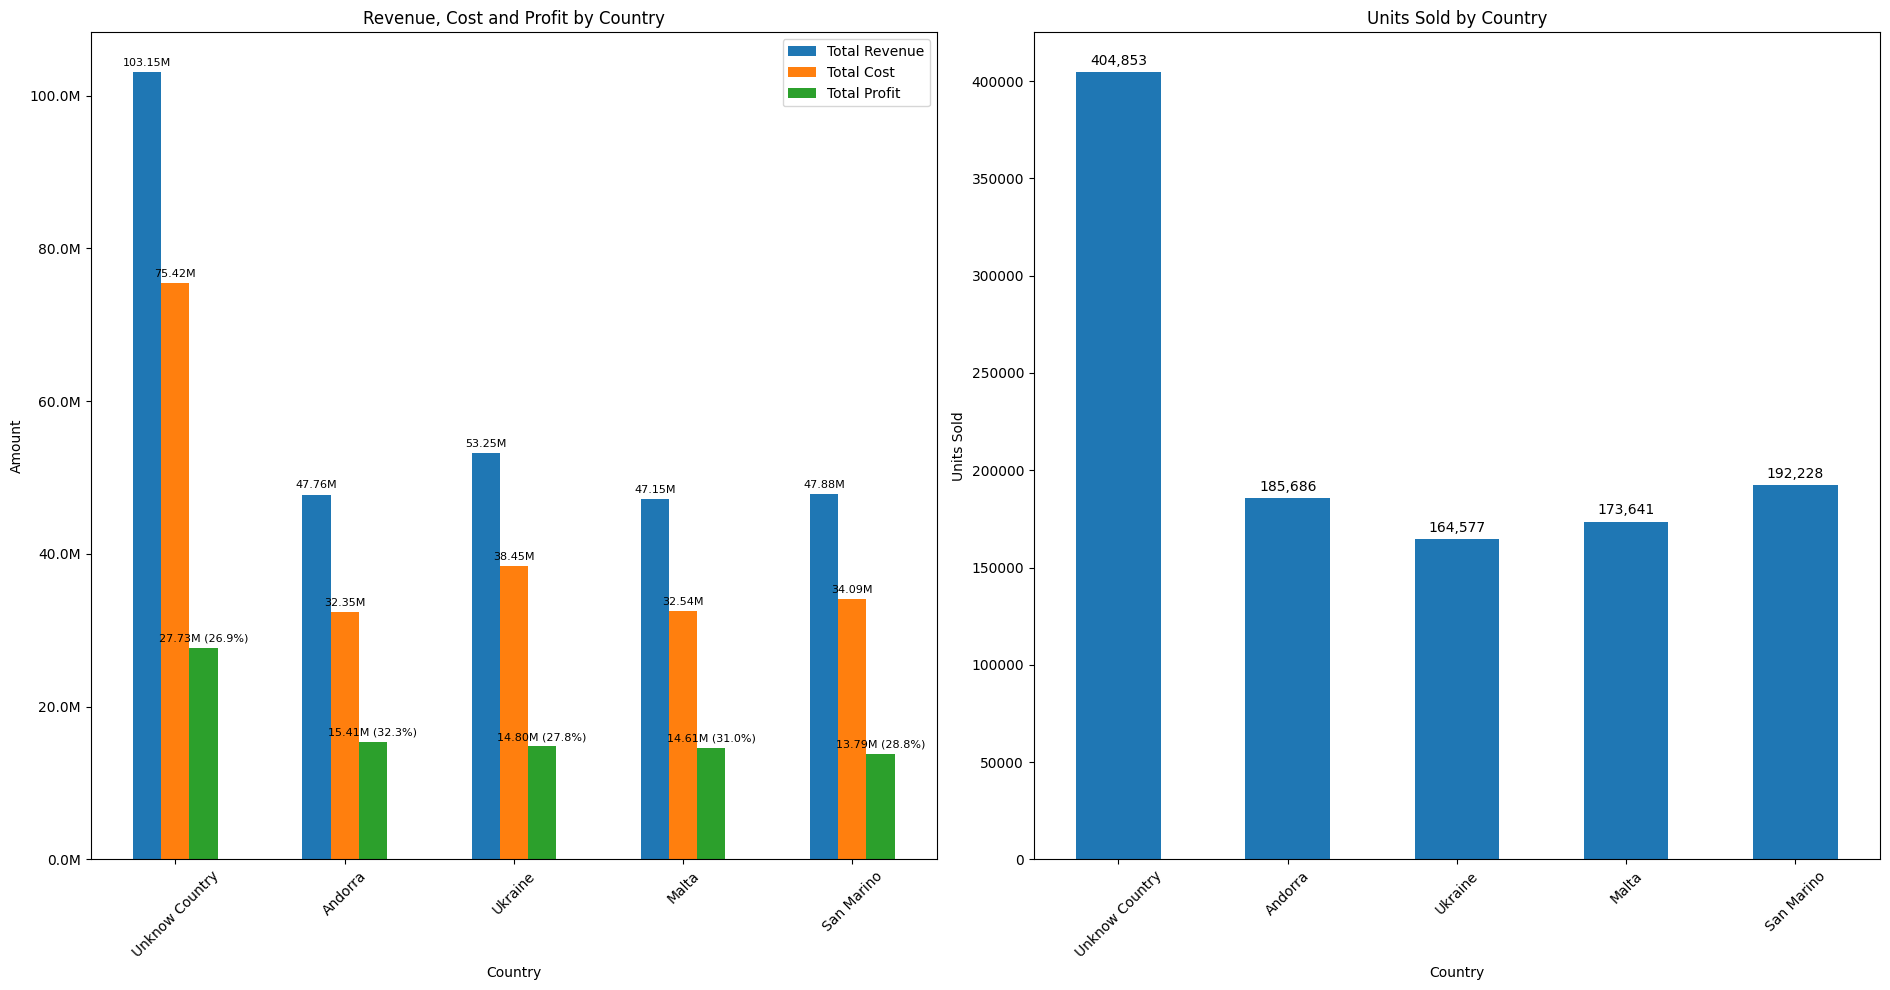

In [85]:
fig, ax = plt.subplots(1, 2, figsize=(19, 10))

country[["Total Revenue", "Total Cost", "Total Profit"]].plot(
    kind="bar",
    ax=ax[0],
    rot=45
)

ax[0].set_title("Revenue, Cost and Profit by Country")
ax[0].set_xlabel("Country")
ax[0].set_ylabel("Amount")

ax[0].yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f}M")
)

for container in ax[0].containers:

    labels = []

    for i, value in enumerate(container.datavalues):

        if container.get_label() == "Total Profit":

            margin = country["Profit Margin"].iloc[i]

            labels.append(
                f"{value/1_000_000:.2f}M ({margin:.1f}%)"
            )

        else:

            labels.append(
                f"{value/1_000_000:.2f}M"
            )

    ax[0].bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=8
    )

country_units.plot(
    kind="bar",
    ax=ax[1],
    rot=45
)

ax[1].set_title("Units Sold by Country")
ax[1].set_xlabel("Country")
ax[1].set_ylabel("Units Sold")

for i, value in enumerate(country_units.values):
    ax[1].annotate(
        f"{value:,.0f}",
        xy=(i, value),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

По країнам особливо сказати не можу, доволі однаково себе показують

У нас є невідома країна яка має доволі непогані значення треба буде перевірити що не так з базою щоб далі уникнути невідому країну

Візуалізація по каналам продажу:

In [86]:
channel = (
    events.groupby("Sales Channel")[["Total Revenue", "Total Cost", "Total Profit"]]
    .sum()
)

channel["Profit Margin"] = (
    channel["Total Profit"] / channel["Total Revenue"] * 100
).round(1)

channel_count = (
    events.groupby("Sales Channel")["Units Sold"]
    .sum()
)

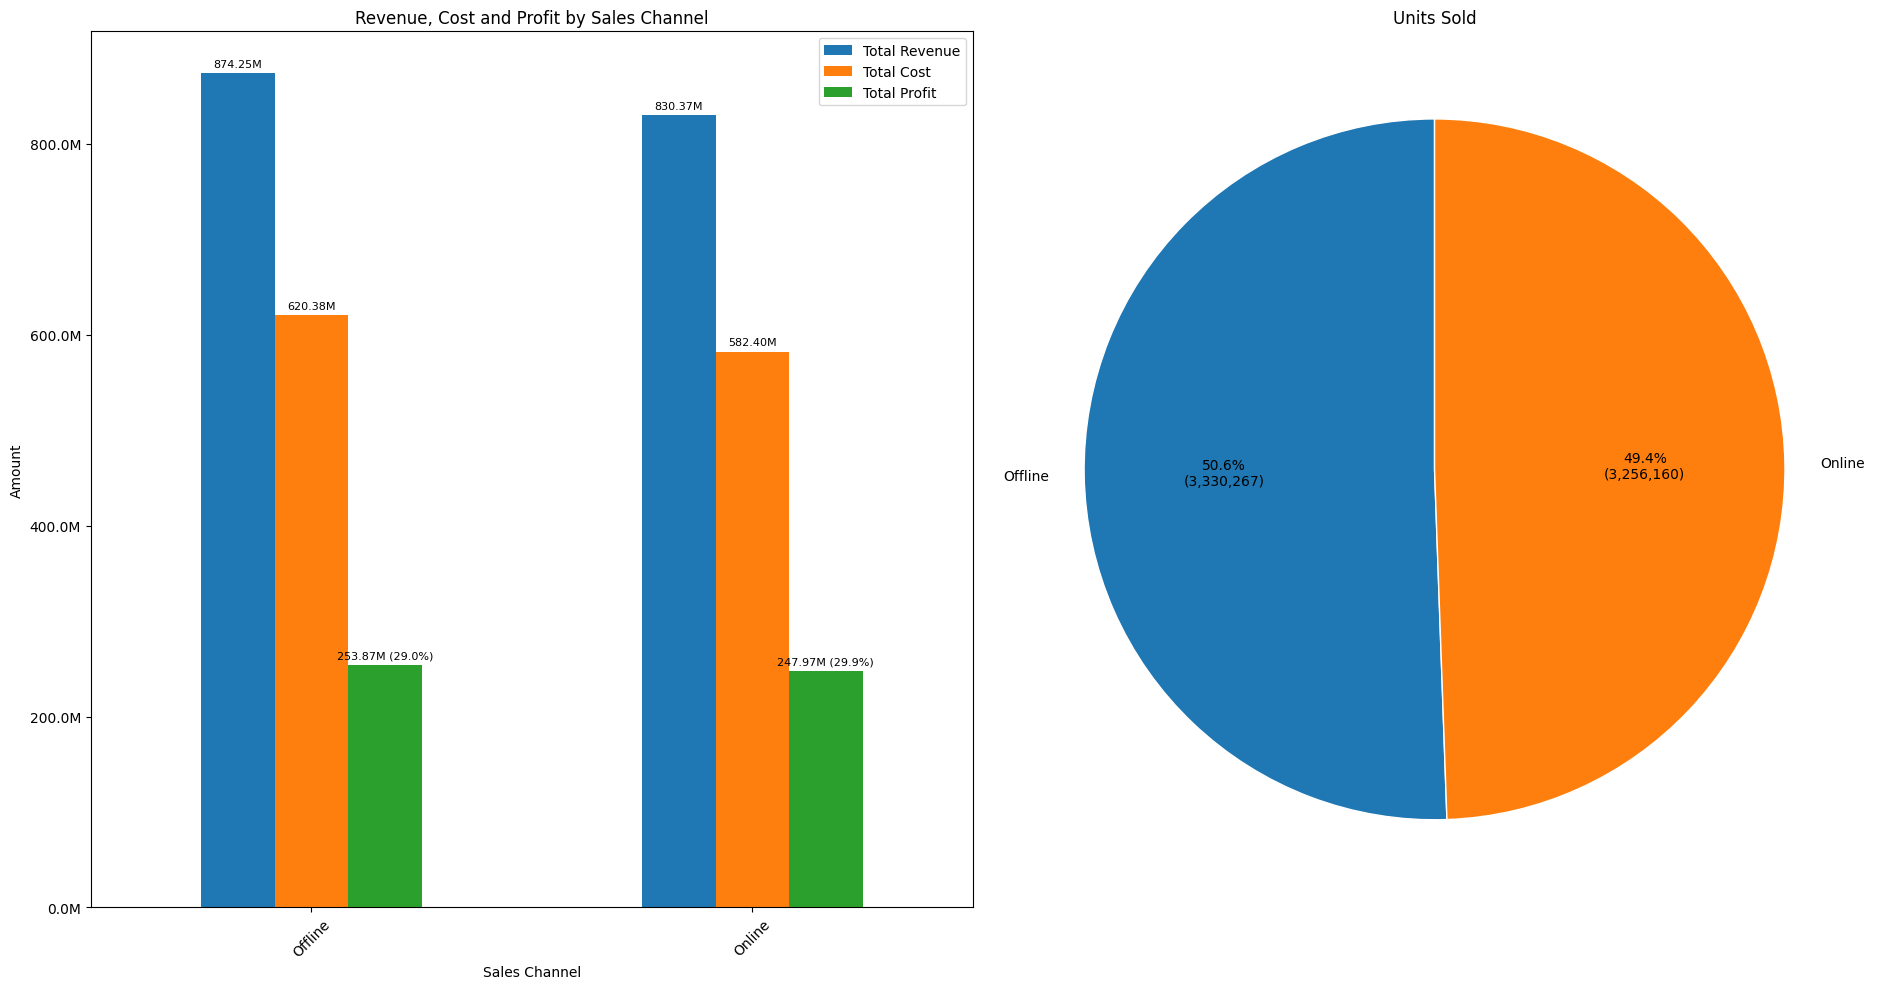

In [87]:
fig, ax = plt.subplots(1, 2, figsize=(19, 10))

channel[["Total Revenue", "Total Cost", "Total Profit"]].plot(
    kind="bar",
    ax=ax[0],
    rot=45
)

ax[0].set_title("Revenue, Cost and Profit by Sales Channel")
ax[0].set_xlabel("Sales Channel")
ax[0].set_ylabel("Amount")

ax[0].yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f}M")
)

for container in ax[0].containers:

    labels = []

    for i, value in enumerate(container.datavalues):

        if container.get_label() == "Total Profit":

            margin = channel["Profit Margin"].iloc[i]

            labels.append(
                f"{value/1_000_000:.2f}M ({margin:.1f}%)"
            )

        else:

            labels.append(
                f"{value/1_000_000:.2f}M"
            )

    ax[0].bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=8
    )

channel_count.plot(
    kind="pie",
    ax=ax[1],
    autopct=lambda p: f"{p:.1f}%\n({int(p / 100 * channel_count.sum()):,})",
    startangle=90,
    wedgeprops={"edgecolor": "white"}
)

ax[1].set_title("Units Sold")
ax[1].set_ylabel("")

plt.tight_layout()
plt.show()

У онлайна прибуток трішки більше на 0.9 % тому можна продовжувати в такому темпі

Проаналізуємо інтервал часу між замовленням та його відвантаженням та зроби відповідні візуалізації в розрізі:

* категорій товарів
* країн
* регіонів

In [88]:
events.head()

,Order Id,Order Date,Ship Date,Order Priority,Country Code,Product Id,Sales Channel,Units Sold,Unit Price,Unit Cost,Category,Country,Region,Sub-Region,Total Revenue,Total Cost,Total Profit,Count Day
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50,10
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87,0
2,101025998,2014-07-18,2014-08-11,M,UNKNOWN,7940,Online,4693.0,668.27,502.54,Household,Unknow Country,Unknow Region,Unknow Sub-Region,3136191.11,2358420.22,777770.89,24
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24,31
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68,38


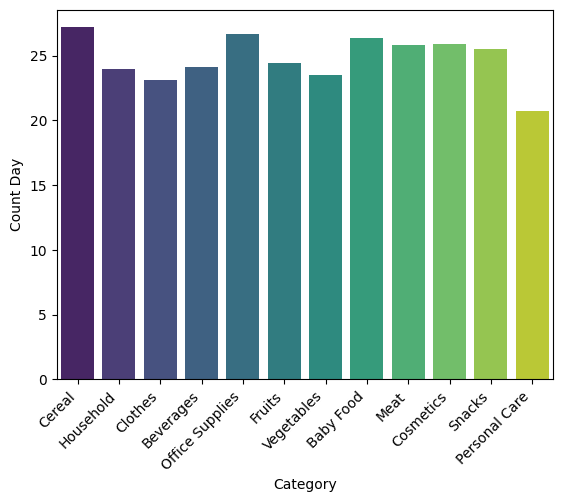

In [89]:
# Пробуємо візуалізувати через seabor
sns.barplot(data= events, x="Category", y= "Count Day", errorbar= None, palette= "viridis", hue="Category")
plt.xticks(rotation=45, ha="right")

plt.show()

У найпопулярнішого товара по прибутку (***Office Suplice***) в середньому найбільший інтервал відвантаження можливо спробувати змінити спосіб відвантажання і глянути що це змінить у відношені  прибутку і профіта

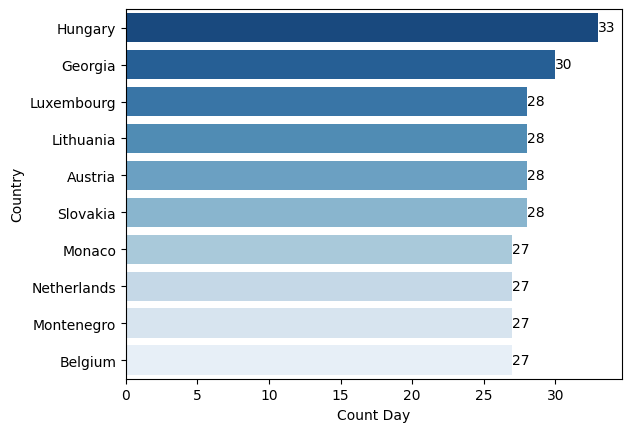

In [90]:
country = events.groupby("Country")["Count Day"].mean().round(0).sort_values(ascending= False).head(10).reset_index()
country
sns.barplot(data= country, y="Country", x= "Count Day", errorbar= None, palette="Blues_r", hue= "Country")


for i in plt.gca().containers:
  plt.gca().bar_label(i)
plt.show()

По країнах час відвантаження майже однаковий нічого немає сказати

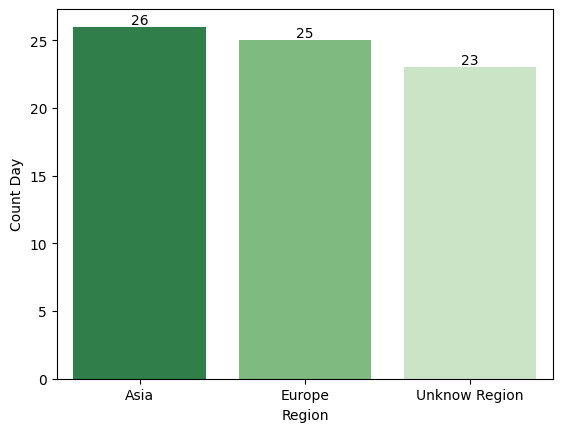

In [91]:
region = events.groupby("Region")["Count Day"].mean().round(0).sort_values(ascending= False).head(10).reset_index()
country
sns.barplot(data= region, x="Region", y= "Count Day", errorbar= None, palette= "Greens_r", hue="Region" )


for i in plt.gca().containers:
  plt.gca().bar_label(i)
plt.show()

В регіонах ситуація середній час відвантаження менший на один глобально нічого це не міняє

Аналізуємо, чи залежить прибуток від часу, необхідного на відвантаження товару

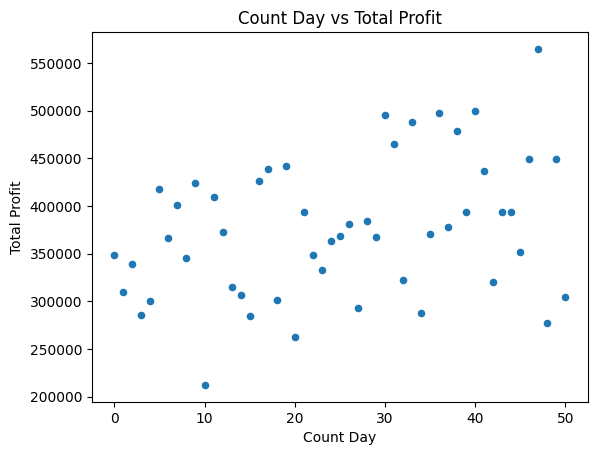

In [92]:
shiping_profit = events.groupby("Count Day")["Total Profit"].mean().reset_index()
shiping_profit.plot(kind = "scatter", x= "Count Day", y= "Total Profit")
plt.title("Count Day vs Total Profit")
plt.show()

Точки розтавлено хаотично, час доставки ніяк не впливає на профіт

Розглнемо динаміку продажів по часу

* По категорія

* Країн

* Регіонів

In [93]:
# Щоб було зручніше додамо до нашої табличкі роки
events["Year Order"] = events["Order Date"].dt.to_period("Y").dt.strftime("%Y")
# перевіряємо
events.head()

,Order Id,Order Date,Ship Date,Order Priority,Country Code,Product Id,Sales Channel,Units Sold,Unit Price,Unit Cost,Category,Country,Region,Sub-Region,Total Revenue,Total Cost,Total Profit,Count Day,Year Order
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50,10,2014
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87,0,2016
2,101025998,2014-07-18,2014-08-11,M,UNKNOWN,7940,Online,4693.0,668.27,502.54,Household,Unknow Country,Unknow Region,Unknow Sub-Region,3136191.11,2358420.22,777770.89,24,2014
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24,31,2017
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68,38,2012


In [94]:
# Почнемо загалні продажі по рокам
years = events.groupby("Year Order")["Order Id"].count().reset_index()


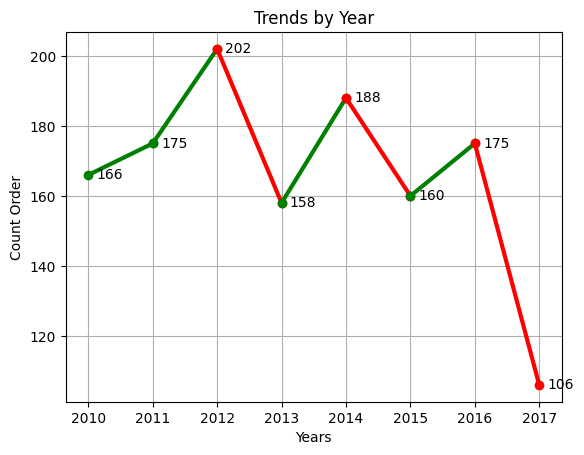

In [95]:
for i in range(len(years)-1):

    if years["Order Id"].iloc[i+1] >= years["Order Id"].iloc[i]:
        color = "green"
    else:
        color = "red"

    plt.plot(
        years["Year Order"].iloc[i:i+2],
        years["Order Id"].iloc[i:i+2],
        color=color,
        linewidth=3,
        marker = "o"
    )

for i in range(len(years["Order Id"])):
  plt.annotate(years["Order Id"][i],(years["Year Order"][i], years["Order Id"][i]),
               xytext=(6, 0),
               textcoords="offset points",
              ha="left",
              va="center"

               )
  plt.title("Trends by Year")
  plt.xlabel("Years")
  plt.ylabel("Count Order")

plt.grid(True)
plt.show()

На цьому графіку ми замітили сезоність з 2010 по 2012 кількість продажів росла потім то піднімається то опускається хоча спроби дійти до максимума були але невдалі

з 2016 року до 207 продажі значно впали

In [96]:
# Продовжуємо по категоріям візмемо топ 5 категорій за кількістю проданих товарів
top5 = events.groupby("Category")["Order Id"].count().nlargest(5).index
years_top = events[events["Category"].isin(top5)]
years = years_top.groupby(["Category", "Year Order"])["Order Id"].count().reset_index()
years


,Category,Year Order,Order Id
0,Beverages,2010,15
1,Beverages,2011,12
2,Beverages,2012,16
3,Beverages,2013,16
4,Beverages,2014,12
5,Beverages,2015,18
6,Beverages,2016,19
7,Beverages,2017,13
8,Cosmetics,2010,12
9,Cosmetics,2011,17


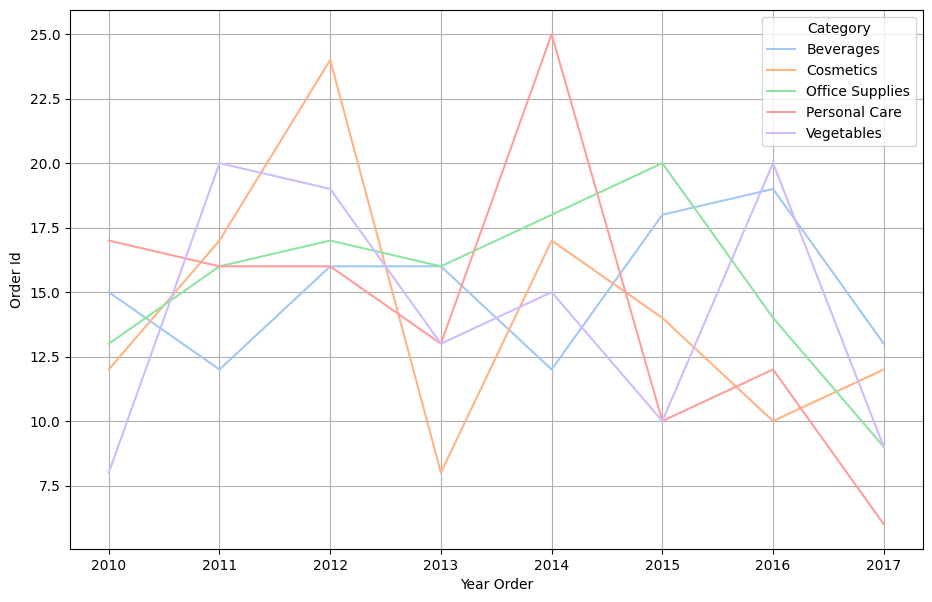

In [97]:
plt.figure(figsize=(11,7))
sns.lineplot(
    data=years,
    x="Year Order",
    y="Order Id",
    color="royalblue",
    hue= "Category",
    palette="pastel"
)
plt.grid(True)
plt.show()

Бачимо, що сезонність вплинула не лише на загальні продажі, а й на окремі категорії товарів. Більшість категорій демонстрували зростання обсягів продажів у період з **2010 по 2012 рік**, після чого спостерігається тенденція до зниження. У наступні роки були окремі спроби відновити рівень продажів, однак вони не призвели до стійкого зростання, і загальна тенденція залишилася спадною.


In [98]:
# Так само по країнах візмемо топ 5 категорій за кількістю проданих товарів
top5 = events.groupby("Country")["Order Id"].count().nlargest(5).index
country_top = events[events["Country"].isin(top5)]
country = country_top.groupby(["Country", "Year Order"])["Order Id"].count().reset_index()
country

,Country,Year Order,Order Id
0,Andorra,2010,8
1,Andorra,2011,4
2,Andorra,2012,4
3,Andorra,2013,5
4,Andorra,2014,4
5,Andorra,2015,3
6,Andorra,2016,9
7,Andorra,2017,3
8,Bosnia And Herzegovina,2010,3
9,Bosnia And Herzegovina,2011,4


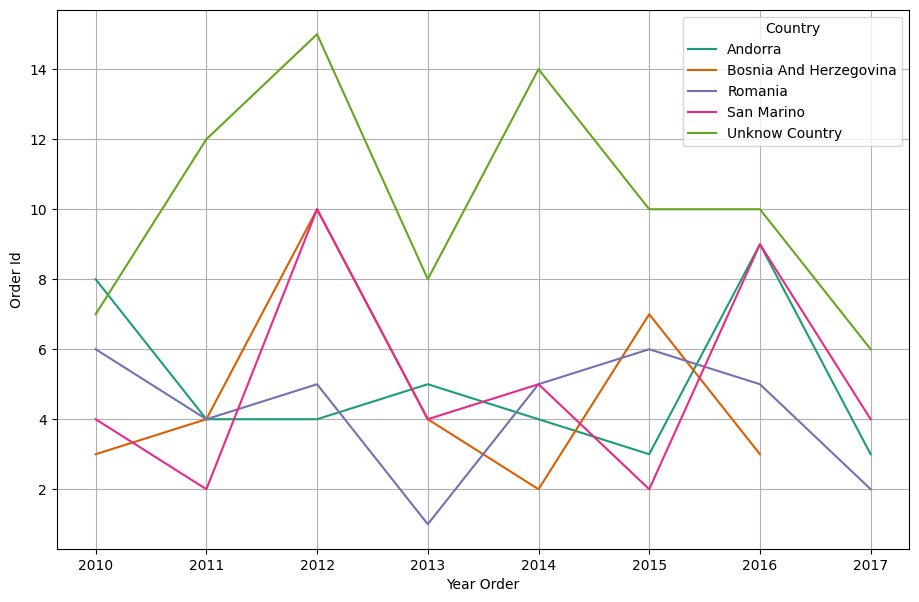

In [99]:
plt.figure(figsize=(11,7))
sns.lineplot(
    data= country,
    x="Year Order",
    y="Order Id",
    color="royalblue",
    hue= "Country",
    palette="Dark2"
 )
plt.grid(True)
plt.show()

У країнах така сама ситуація з 2010 до 2012 продажі росли потім то вниз то вверх

In [100]:
# Так само подиdbvjcm по регіонах
region = events.groupby(["Region", "Year Order"])["Order Id"].count().reset_index()
region

,Region,Year Order,Order Id
0,Asia,2010,11
1,Asia,2011,9
2,Asia,2012,15
3,Asia,2013,9
4,Asia,2014,12
5,Asia,2015,11
6,Asia,2016,8
7,Asia,2017,7
8,Europe,2010,148
9,Europe,2011,154


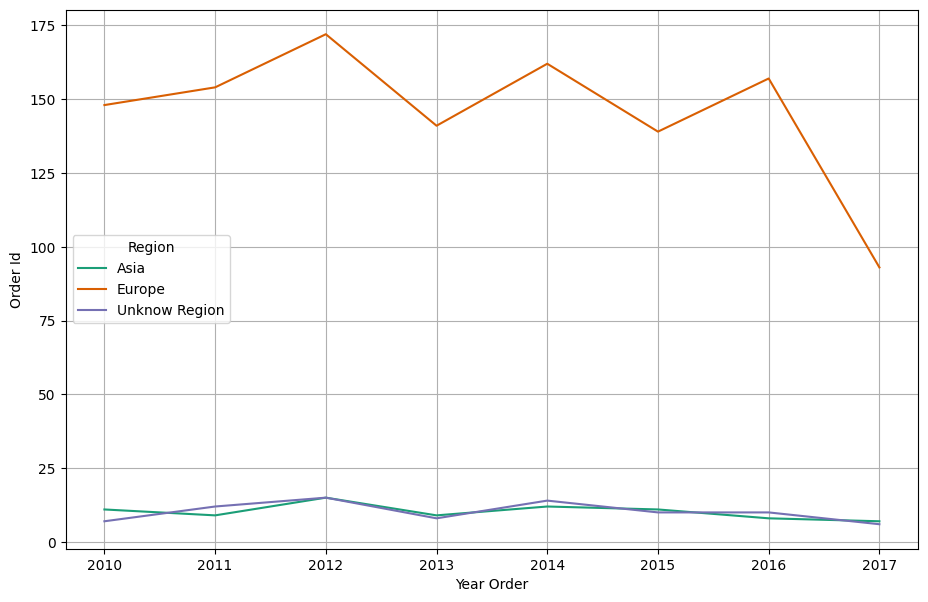

In [101]:
plt.figure(figsize=(11,7))
sns.lineplot(
    data= region,
    x="Year Order",
    y="Order Id",
    color="royalblue",
    hue= "Region",
    palette="Dark2"
 )
plt.grid(True)
plt.show()

По регіонах також є спад але не дуже великий

In [102]:
# Подивимось як продається товари по днях дізнаємочь чи є сезоність спочатку додаємо назву дня тижня
events['Day Name'] = events["Order Date"].dt.day_name()
events.head()

,Order Id,Order Date,Ship Date,Order Priority,Country Code,Product Id,Sales Channel,Units Sold,Unit Price,Unit Cost,Category,Country,Region,Sub-Region,Total Revenue,Total Cost,Total Profit,Count Day,Year Order,Day Name
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50,10,2014,Wednesday
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87,0,2016,Thursday
2,101025998,2014-07-18,2014-08-11,M,UNKNOWN,7940,Online,4693.0,668.27,502.54,Household,Unknow Country,Unknow Region,Unknow Sub-Region,3136191.11,2358420.22,777770.89,24,2014,Friday
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24,31,2017,Saturday
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68,38,2012,Saturday


In [103]:
# Побачимо як продаються категоріїї які зробили найбільше продаж за тиждень
top5 = events.groupby("Category")["Order Id"].count().nlargest(5).index
day_top = events[events["Category"].isin(top5)]
day = day_top.groupby(["Category", "Day Name"])["Order Id"].count().reset_index()
day

,Category,Day Name,Order Id
0,Beverages,Friday,12
1,Beverages,Monday,21
2,Beverages,Saturday,15
3,Beverages,Sunday,21
4,Beverages,Thursday,18
5,Beverages,Tuesday,18
6,Beverages,Wednesday,16
7,Cosmetics,Friday,28
8,Cosmetics,Monday,12
9,Cosmetics,Saturday,14


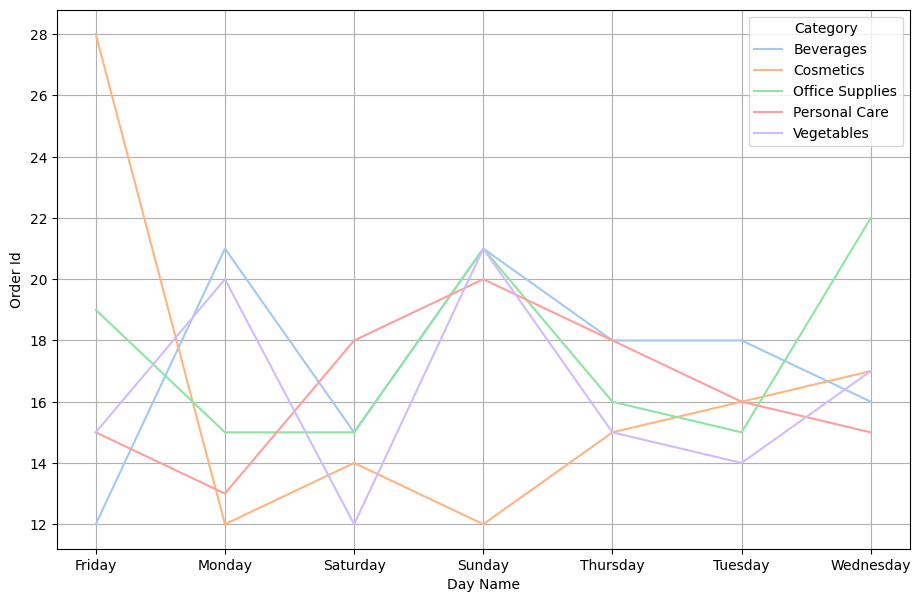

In [104]:
plt.figure(figsize=(11,7))
sns.lineplot(
    data=day,
    x="Day Name",
    y="Order Id",
    color="royalblue",
    hue= "Category",
    palette="pastel"
)
plt.grid(True)
plt.show()

По днях тижня також є сезоність починається з нвого тижня кількість то корилюється ближче до вихідних кількість зростає

## Загальний висновок

За результатами аналізу можна зробити висновок, що **кількість проданих товарів поступово зменшується з року в рік**. Найвищі показники продажів спостерігалися у період **2010–2012 років**, після чого почався спад. Це може свідчити про зміну попиту, посилення конкуренції або недостатню ефективність поточної маркетингової стратегії.

### Рекомендації

* Переглянути маркетингову стратегію та рекламні кампанії, щоб стимулювати зростання продажів.
* Збільшити увагу до ринку **Азії**, оскільки цей регіон демонструє високі показники виручки, прибутку та обсягів продажів.
* Провести додатковий аналіз причин зниження продажів після 2012 року та визначити категорії товарів, які потребують оновлення або більш активного просування.

### Фінальний висновок

Попри зниження обсягів продажів, компанія демонструє **Profit Margin на рівні 29,44%**, тобто майже **30% від отриманої виручки перетворюється на прибуток**. Це є хорошим показником рентабельності. Якщо компанії вдасться збільшити кількість продажів без суттєвого збільшення витрат, це позитивно вплине на загальний прибуток та фінансові результати бізнесу.
